# Project T Demo: Real vs. Fake Face Classification

**Group Name:** IowaGPT  
**Members:** Amit Boodhoo, Diego Liogon, Eva Singh, Kate Meyer

This notebook demonstrates the final trained model on 10 independent images collected outside the Kaggle training dataset. It intentionally does **not** contain any training code, matching the Project T handout requirement for a separate demo notebook.

Run `Project_T_Train.ipynb` first so `resnet18_fake_faces.pt` contains a trained checkpoint.

In [ ]:
# If running in a new VS Code, Jupyter, or Colab environment, uncomment this cell first.
#%pip install torch torchvision matplotlib pandas scikit-learn pillow

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\kmeyer12\\Downloads\\AIML\\Lib\\site-packages\\torchvision\\_C.pyd'
Consider using the `--user` option or check the permissions.



In [ ]:
import os
# Prevent potential crashes related to duplicate library loads in some environments
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision import models, transforms

PROJECT_DIR = Path.cwd()
# Adjust path if running from a parent directory instead of the project folder
if not (PROJECT_DIR / "Project_T_Demo.ipynb").exists() and (PROJECT_DIR / "Project_T" / "Project_T_Demo.ipynb").exists():
    PROJECT_DIR = PROJECT_DIR / "Project_T"
MODEL_PATH = PROJECT_DIR / "resnet18_fake_faces.pt"
CUSTOM_DIR = PROJECT_DIR / "10_Custom_Test_Images"
LABELS_PATH = CUSTOM_DIR / "custom_test_labels.csv"

# Automatically select the best available hardware (NVIDIA GPU, Apple Silicon, or CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Diagnostic output to confirm environment setup
print(f"Using device: {device}")
print(f"Model path: {MODEL_PATH}")
print(f"Custom image folder: {CUSTOM_DIR}")

Using device: cpu
Model path: c:\Users\kmeyer12\aiml\2026jlnb\AIML2026Projects\Project_T\resnet18_fake_faces.pt
Custom image folder: c:\Users\kmeyer12\aiml\2026jlnb\AIML2026Projects\Project_T\10_Custom_Test_Images


In [ ]:
# Ensure the model file exists and isn't a corrupted 0-byte file
if not MODEL_PATH.exists() or MODEL_PATH.stat().st_size == 0:
    raise FileNotFoundError(
        "resnet18_fake_faces.pt is missing or empty. Run Project_T_Train.ipynb first and make sure the final save cell succeeds."
    )

# Load the weights/checkpoint onto the selected hardware (CPU/GPU/MPS)
checkpoint = torch.load(MODEL_PATH, map_location=device)

# Check if the saved file is a structured dictionary (with metadata) or just raw weights
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    # Extract metadata if available, otherwise use standard defaults
    class_names = checkpoint.get("class_names", ["fake", "real"])
    image_size = checkpoint.get("image_size", 224)
    normalize_mean = checkpoint.get("normalize_mean", [0.485, 0.456, 0.406])
    normalize_std = checkpoint.get("normalize_std", [0.229, 0.224, 0.225])
    state_dict = checkpoint["model_state_dict"]
else:
    # Backward-compatible path if the file contains only a state_dict.
    class_names = ["fake", "real"]
    image_size = 224
    normalize_mean = [0.485, 0.456, 0.406]
    normalize_std = [0.229, 0.224, 0.225]
    state_dict = checkpoint

# Initialize ResNet18 and modify the final fully connected layer to match our class count
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Define the pipeline to convert raw images into tensors ready for the model
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(normalize_mean, normalize_std),
])

print("Loaded model successfully.")
print("Class names:", class_names)

Loaded model successfully.
Class names: ['fake', 'real']


In [ ]:
labels_df = pd.read_csv(LABELS_PATH)
# Verify that the CSV has the necessary headers for processing
required_columns = {"filename", "label"}
if not required_columns.issubset(labels_df.columns):
    raise ValueError(f"{LABELS_PATH} must contain columns: {required_columns}")

# Cross-reference the CSV list with the actual files in the directory
missing = [name for name in labels_df["filename"] if not (CUSTOM_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing custom images: {missing}")

# Create a mapping ("fake": 0, "real": 1) to convert text to numeric indices
label_to_idx = {name: i for i, name in enumerate(class_names)}
labels_df["true_idx"] = labels_df["label"].map(label_to_idx)
if labels_df["true_idx"].isna().any():
    bad_labels = labels_df.loc[labels_df["true_idx"].isna(), "label"].tolist()
    raise ValueError(f"Labels not found in model class names {class_names}: {bad_labels}")

# Display a preview of the validated dataset
print(labels_df[["filename", "label", "source"]])

          filename label                      source
0  Fake_Image1.jpg  fake  ThisPersonDoesNotExist.com
1  Fake_Image2.jpg  fake  ThisPersonDoesNotExist.com
2  Fake_Image3.jpg  fake  ThisPersonDoesNotExist.com
3  Fake_Image4.jpg  fake  ThisPersonDoesNotExist.com
4  Fake_Image5.jpg  fake  ThisPersonDoesNotExist.com
5    Real_Amit.jpg  real   Personal Linkedin Picture
6   Real_Diego.jpg  real   Personal Linkedin Picture
7     Real_Eva.jpg  real   Personal Linkedin Picture
8    Real_Kate.jpg  real   Personal Linkedin Picture
9   Real_Lydia.jpg  real   Personal Linkedin Picture


In [ ]:
# Processes a single image and returns the prediction results.
# Returns: Original image, predicted index, max confidence score, and raw probabilities.
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Disable gradient calculation to save memory and speed up inference
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0].cpu().numpy()

    # Determine the class with the highest probability
    pred_idx = int(np.argmax(probs))
    return image, pred_idx, float(probs[pred_idx]), probs

rows = []
images_for_plot = []
for _, row in labels_df.iterrows():
    image_path = CUSTOM_DIR / row["filename"]
    image, pred_idx, confidence, probs = predict_image(image_path)
    true_idx = int(row["true_idx"])
    # Store results for data analysis
    rows.append({
        "filename": row["filename"],
        "true_label": row["label"],
        "predicted_label": class_names[pred_idx],
        "confidence": confidence,
        "correct": pred_idx == true_idx,
    })
    # Store data specifically for the upcoming visualization step
    images_for_plot.append((image, row["filename"], row["label"], class_names[pred_idx], confidence))
# Combine all findings into a final summary DataFrame
results_df = pd.DataFrame(rows)
results_df

,filename,true_label,predicted_label,confidence,correct
0,Fake_Image1.jpg,fake,fake,0.900232,True
1,Fake_Image2.jpg,fake,fake,0.858925,True
2,Fake_Image3.jpg,fake,real,0.692453,False
3,Fake_Image4.jpg,fake,fake,0.906917,True
4,Fake_Image5.jpg,fake,fake,0.898370,True
5,Real_Amit.jpg,real,real,0.977574,True
6,Real_Diego.jpg,real,real,0.915280,True
7,Real_Eva.jpg,real,real,0.890149,True
8,Real_Kate.jpg,real,real,0.585600,True
9,Real_Lydia.jpg,real,real,0.992764,True


Custom 10-image demo accuracy: 0.9000
              precision    recall  f1-score   support

        fake       1.00      0.80      0.89         5
        real       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



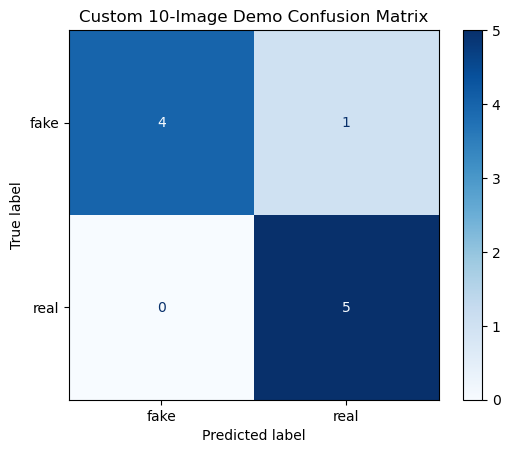

In [ ]:
# Evaluation Metrics

#Calculate the overall percentage of correct predictions
demo_accuracy = accuracy_score(results_df["true_label"], results_df["predicted_label"])
print(f"Custom 10-image demo accuracy: {demo_accuracy:.4f}")
print(classification_report(results_df["true_label"], results_df["predicted_label"], labels=class_names, zero_division=0))

# Visulation with COnfusion Matrix
# Create a matrix to see exactly which classes are being misidentified
cm = confusion_matrix(results_df["true_label"], results_df["predicted_label"], labels=class_names)
# Display the matrix using a blue color map for better readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Custom 10-Image Demo Confusion Matrix")
plt.show()

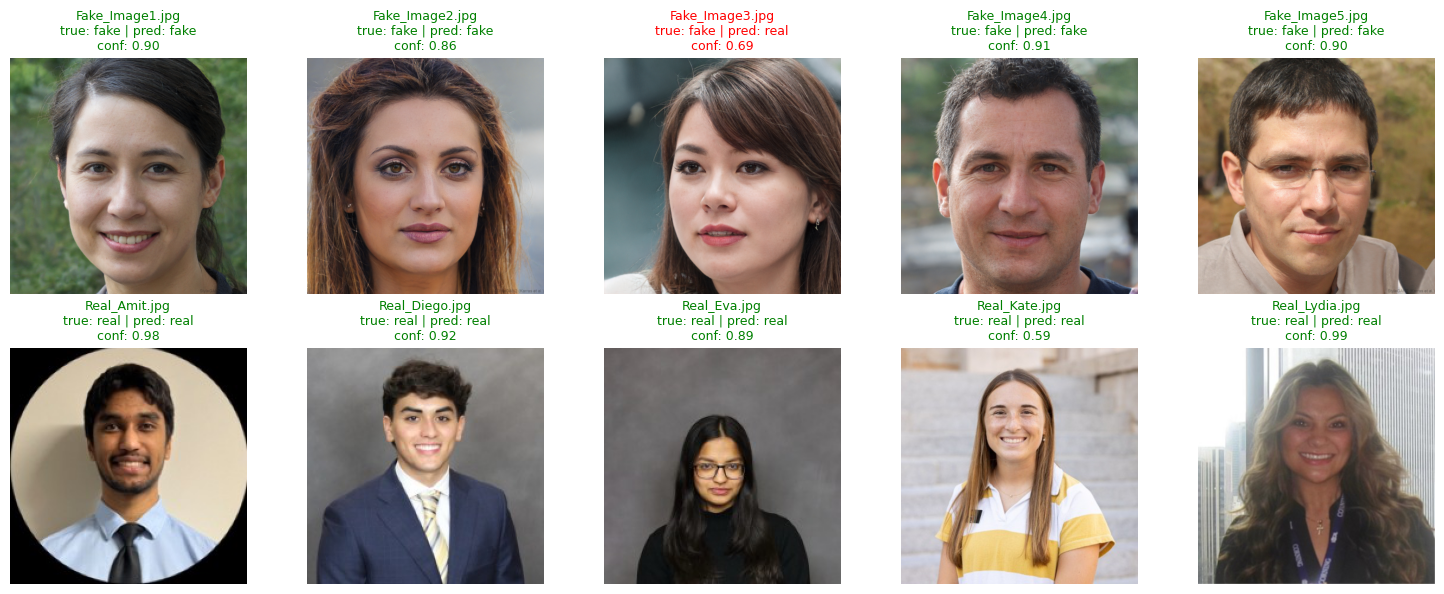

In [ ]:
# Visual Results
# Set up a grid layout based on the number of images (5 columns across)
cols = 5
rows = int(np.ceil(len(images_for_plot) / cols))
plt.figure(figsize=(15, 3 * rows))

for i, (image, filename, true_label, predicted_label, confidence) in enumerate(images_for_plot, start=1):
    # Create a subplot for each image in the grid
    ax = plt.subplot(rows, cols, i)
    ax.imshow(image)
    ax.axis("off")
    # Use green text for correct predictions and red for mistakes
    color = "green" if true_label == predicted_label else "red"
    # Format the caption with filename, comparison, and the model's confidence level
    title = f"{filename}\ntrue: {true_label} | pred: {predicted_label}\nconf: {confidence:.2f}"
    ax.set_title(title, fontsize=9, color=color)
# Adjust spacing so titles and images don't overlap
plt.tight_layout()
plt.show()

## Source Notes

- `Fake_Image1.jpg`, `Fake_Image2.jpg` , `Fake_Image3.jpg` , `Fake_Image4.jpg` , and `Fake_Image5.jpg` were collected from ThisPersonDoesNotExist.com.
- The real images are taken from our own Linkedin Profiles, including this course's TA, Lydia, to meet the 10 image requirement. 
- These 10 examples are independent from the Kaggle dataset used for training, validation, and held-out testing.